In [2]:
# Cell 1 — Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# Cell 2 — Load Data
patients = pd.read_csv('../data/raw/csv/patients.csv')
encounters = pd.read_csv('../data/raw/csv/encounters.csv')
conditions = pd.read_csv('../data/raw/csv/conditions.csv')
medications = pd.read_csv('../data/raw/csv/medications.csv')
procedures = pd.read_csv('../data/raw/csv/procedures.csv')

print("patients:", patients.shape)
print("encounters:", encounters.shape)
print("conditions:", conditions.shape)
print("medications:", medications.shape)
print("procedures:", procedures.shape)

patients: (1171, 25)
encounters: (53346, 15)
conditions: (8376, 6)
medications: (42989, 13)
procedures: (34981, 8)


In [4]:
# Cell 3 — First look at patients
print("=== PATIENTS ===")
print(patients.head())
print("\n=== COLUMN NAMES ===")
print(patients.columns.tolist())
print("\n=== MISSING VALUES ===")
print(patients.isnull().sum())
print("\n=== DATA TYPES ===")
print(patients.dtypes)

=== PATIENTS ===
                                     Id   BIRTHDATE DEATHDATE          SSN  \
0  1d604da9-9a81-4ba9-80c2-de3375d59b40  1989-05-25       NaN  999-76-6866   
1  034e9e3b-2def-4559-bb2a-7850888ae060  1983-11-14       NaN  999-73-5361   
2  10339b10-3cd1-4ac3-ac13-ec26728cb592  1992-06-02       NaN  999-27-3385   
3  8d4c4326-e9de-4f45-9a4c-f8c36bff89ae  1978-05-27       NaN  999-85-4926   
4  f5dcd418-09fe-4a2f-baa0-3da800bd8c3a  1996-10-18       NaN  999-60-7372   

     DRIVERS    PASSPORT PREFIX            FIRST           LAST SUFFIX  \
0  S99984236  X19277260X    Mr.  José Eduardo181       Gómez206    NaN   
1  S99962402  X88275464X    Mr.          Milo271        Feil794    NaN   
2  S99972682  X73754411X    Mr.        Jayson808       Fadel536    NaN   
3  S99974448  X40915583X   Mrs.       Mariana775  Rutherford999    NaN   
4  S99915787  X86772962X    Mr.      Gregorio366         Auer97    NaN   

          MAIDEN MARITAL   RACE    ETHNICITY GENDER  \
0            N

In [6]:
# Cell 4 — Explore Encounters
print("=== ENCOUNTERS ===")
print(encounters.head())
print("\n=== COLUMN NAMES ===")
print(encounters.columns.tolist())
print("\n=== ENCOUNTER TYPES ===")
print(encounters['ENCOUNTERCLASS'].value_counts())
print("\n=== MISSING VALUES ===")
print(encounters.isnull().sum())


print("=== PATIENTS ===")
print(patients.head())
print("\n=== COLUMN NAMES ===")
print(patients.columns.tolist())
print("\n=== MISSING VALUES ===")
print(patients.isnull().sum())

=== ENCOUNTERS ===
                                     Id                 START  \
0  d0c40d10-8d87-447e-836e-99d26ad52ea5  2010-01-23T17:45:28Z   
1  e88bc3a9-007c-405e-aabc-792a38f4aa2b  2012-01-23T17:45:28Z   
2  8f104aa7-4ca9-4473-885a-bba2437df588  2001-05-01T15:02:18Z   
3  b85c339a-6076-43ed-b9d0-9cf013dec49d  2011-07-28T15:02:18Z   
4  dae2b7cb-1316-4b78-954f-fa610a6c6d0e  2010-07-27T12:58:08Z   

                   STOP                               PATIENT  \
0  2010-01-23T18:10:28Z  034e9e3b-2def-4559-bb2a-7850888ae060   
1  2012-01-23T18:00:28Z  034e9e3b-2def-4559-bb2a-7850888ae060   
2  2001-05-01T15:17:18Z  1d604da9-9a81-4ba9-80c2-de3375d59b40   
3  2011-07-28T15:17:18Z  1d604da9-9a81-4ba9-80c2-de3375d59b40   
4  2010-07-27T13:28:08Z  10339b10-3cd1-4ac3-ac13-ec26728cb592   

                           ORGANIZATION                              PROVIDER  \
0  e002090d-4e92-300e-b41e-7d1f21dee4c6  e6283e46-fd81-3611-9459-0edb1c3da357   
1  772ee193-bb9f-30eb-9939-21e86c8e4d

In [7]:
# Cell 5 — Define Target Variable (30-day Readmission)

# Convert dates to datetime
encounters['START'] = pd.to_datetime(encounters['START'])
encounters['STOP'] = pd.to_datetime(encounters['STOP'])

# Filter only inpatient encounters
inpatient = encounters[encounters['ENCOUNTERCLASS'] == 'inpatient'].copy()
inpatient = inpatient.sort_values(['PATIENT', 'START'])

print(f"Total inpatient encounters: {len(inpatient)}")
print(f"Unique patients with inpatient visits: {inpatient['PATIENT'].nunique()}")

# For each inpatient encounter, check if same patient had another 
# inpatient encounter within 30 days of discharge
inpatient['NEXT_ADMISSION'] = inpatient.groupby('PATIENT')['START'].shift(-1)
inpatient['DAYS_TO_READMISSION'] = (inpatient['NEXT_ADMISSION'] - inpatient['STOP']).dt.days
inpatient['READMITTED_30'] = (inpatient['DAYS_TO_READMISSION'] <= 30).astype(int)

print(f"\nReadmission rate: {inpatient['READMITTED_30'].mean():.2%}")
print(f"Readmitted within 30 days: {inpatient['READMITTED_30'].sum()}")
print(f"Not readmitted: {(inpatient['READMITTED_30'] == 0).sum()}")

Total inpatient encounters: 1838
Unique patients with inpatient visits: 283

Readmission rate: 41.84%
Readmitted within 30 days: 769
Not readmitted: 1069


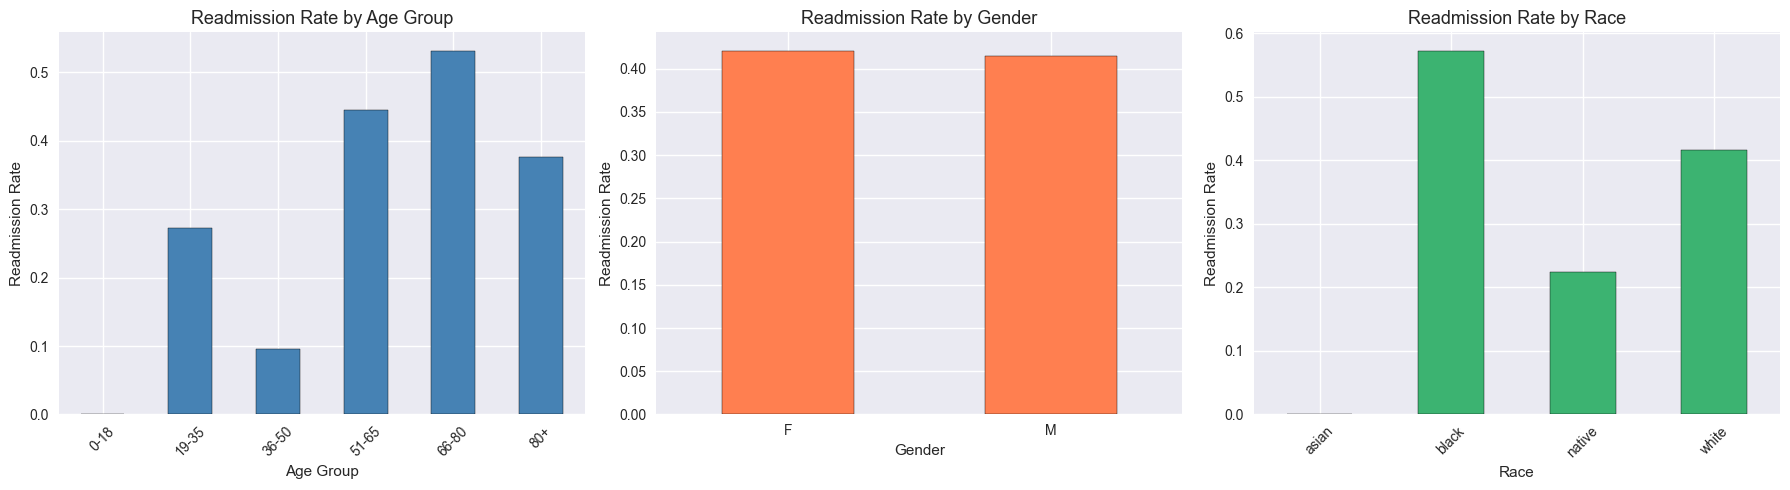

AGE_GROUP
0-18     0.000000
19-35    0.272727
36-50    0.095238
51-65    0.444785
66-80    0.531873
80+      0.375758
Name: READMITTED_30, dtype: float64

 GENDER
F    0.421104
M    0.414907
Name: READMITTED_30, dtype: float64

 RACE
asian     0.000000
black     0.573077
native    0.225000
white     0.416725
Name: READMITTED_30, dtype: float64


In [8]:
# Cell 6 — Patient Demographics Analysis

# Calculate age from birthdate
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
patients['AGE'] = (pd.Timestamp.now() - patients['BIRTHDATE']).dt.days // 365

# Merge inpatient with patients
inpatient_patients = inpatient.merge(patients[['Id', 'AGE', 'GENDER', 'RACE', 'ETHNICITY', 
                                                'MARITAL', 'HEALTHCARE_EXPENSES', 
                                                'HEALTHCARE_COVERAGE', 'DEATHDATE']], 
                                      left_on='PATIENT', right_on='Id', how='left')

# Plot readmission rate by age group
inpatient_patients['AGE_GROUP'] = pd.cut(inpatient_patients['AGE'], 
                                          bins=[0,18,35,50,65,80,100], 
                                          labels=['0-18','19-35','36-50','51-65','66-80','80+'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age group
readmit_age = inpatient_patients.groupby('AGE_GROUP')['READMITTED_30'].mean()
readmit_age.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Readmission Rate by Age Group', fontsize=13)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Readmission Rate')
axes[0].tick_params(axis='x', rotation=45)

# Gender
readmit_gender = inpatient_patients.groupby('GENDER')['READMITTED_30'].mean()
readmit_gender.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Readmission Rate by Gender', fontsize=13)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Readmission Rate')
axes[1].tick_params(axis='x', rotation=0)

# Race
readmit_race = inpatient_patients.groupby('RACE')['READMITTED_30'].mean()
readmit_race.plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Readmission Rate by Race', fontsize=13)
axes[2].set_xlabel('Race')
axes[2].set_ylabel('Readmission Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/demographics_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(readmit_age)
print("\n", readmit_gender)
print("\n", readmit_race)

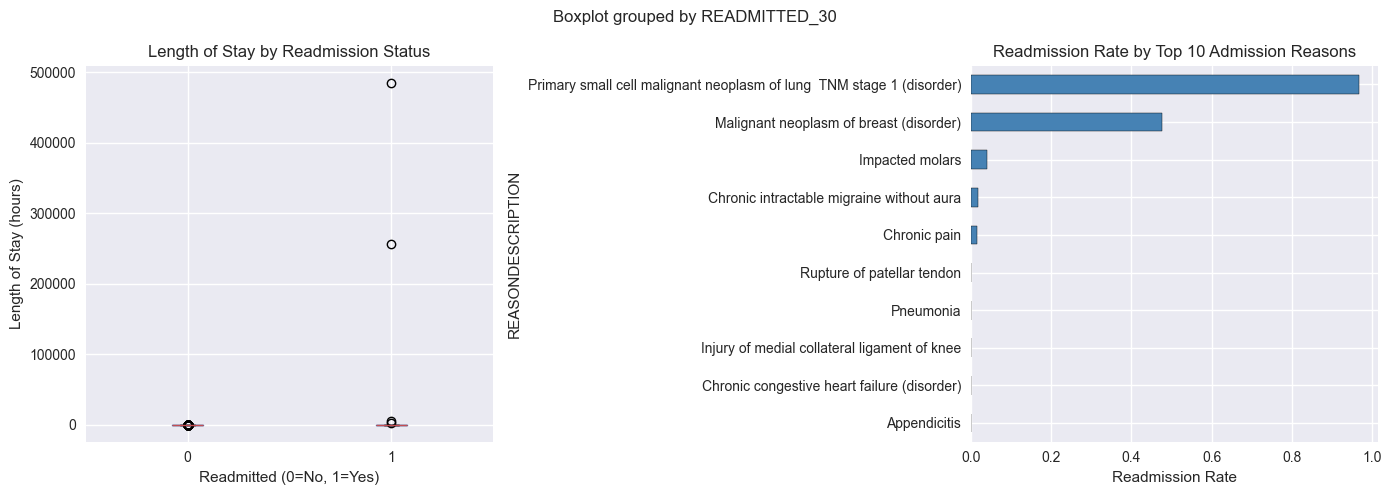

Average length of stay:
                count        mean           std   min        25%    50%   75%  \
READMITTED_30                                                                   
0              1069.0   26.608887     11.022856  24.0  24.000000  24.25  25.0   
1               769.0  997.858149  19766.915257  24.0  24.366667  25.00  26.0   

                         max  
READMITTED_30                 
0                 144.000000  
1              485164.666667  


In [13]:
# Cell 7 — Encounter-level Analysis
inpatient_patients['LENGTH_OF_STAY'] = (inpatient_patients['STOP'] - 
                                         inpatient_patients['START']).dt.total_seconds() / 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length of stay distribution by readmission
inpatient_patients.boxplot(column='LENGTH_OF_STAY', by='READMITTED_30', ax=axes[0])
axes[0].set_title('Length of Stay by Readmission Status')
axes[0].set_xlabel('Readmitted (0=No, 1=Yes)')
axes[0].set_ylabel('Length of Stay (hours)')

# Readmission rate by encounter reason
top_reasons = inpatient_patients['REASONDESCRIPTION'].value_counts().head(10).index
reason_readmit = inpatient_patients[inpatient_patients['REASONDESCRIPTION'].isin(top_reasons)]
reason_readmit = reason_readmit.groupby('REASONDESCRIPTION')['READMITTED_30'].mean().sort_values(ascending=True)
reason_readmit.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Readmission Rate by Top 10 Admission Reasons')
axes[1].set_xlabel('Readmission Rate')

plt.tight_layout()
plt.savefig('../reports/encounter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average length of stay:")
print(inpatient_patients.groupby('READMITTED_30')['LENGTH_OF_STAY'].describe())

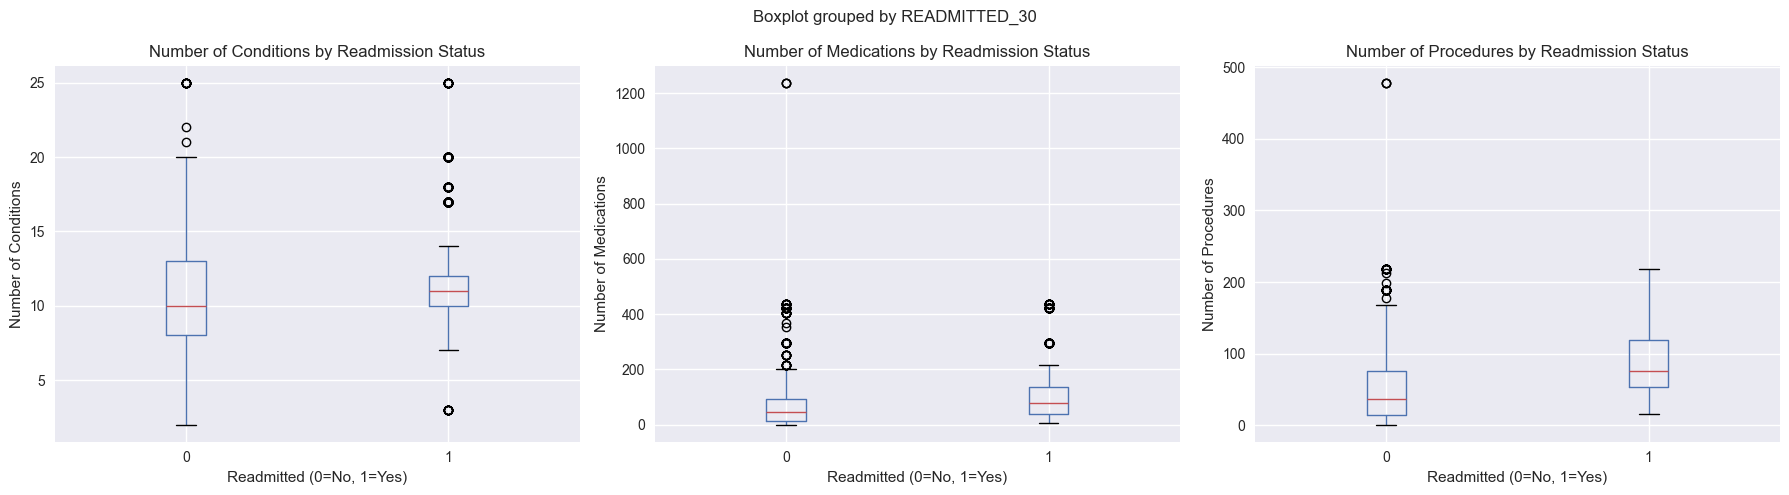

Conditions summary:
READMITTED_30
0    10.724041
1    12.022107
Name: TOTAL_CONDITIONS, dtype: float64

Medications summary:
READMITTED_30
0     77.946679
1    111.858257
Name: TOTAL_MEDICATIONS, dtype: float64

Procedures summary:
READMITTED_30
0    53.549111
1    91.911573
Name: TOTAL_PROCEDURES, dtype: float64


In [14]:
# Cell 8 — Conditions Analysis
# Count number of conditions per patient encounter
conditions['START'] = pd.to_datetime(conditions['START'])

condition_counts = conditions.groupby('PATIENT').size().reset_index(name='TOTAL_CONDITIONS')
inpatient_patients = inpatient_patients.merge(condition_counts, on='PATIENT', how='left')
inpatient_patients['TOTAL_CONDITIONS'] = inpatient_patients['TOTAL_CONDITIONS'].fillna(0)

# Count medications per patient
med_counts = medications.groupby('PATIENT').size().reset_index(name='TOTAL_MEDICATIONS')
inpatient_patients = inpatient_patients.merge(med_counts, on='PATIENT', how='left')
inpatient_patients['TOTAL_MEDICATIONS'] = inpatient_patients['TOTAL_MEDICATIONS'].fillna(0)

# Count procedures per patient
proc_counts = procedures.groupby('PATIENT').size().reset_index(name='TOTAL_PROCEDURES')
inpatient_patients = inpatient_patients.merge(proc_counts, on='PATIENT', how='left')
inpatient_patients['TOTAL_PROCEDURES'] = inpatient_patients['TOTAL_PROCEDURES'].fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color, title in zip(axes, 
    ['TOTAL_CONDITIONS', 'TOTAL_MEDICATIONS', 'TOTAL_PROCEDURES'],
    ['steelblue', 'coral', 'mediumseagreen'],
    ['Conditions', 'Medications', 'Procedures']):
    
    inpatient_patients.boxplot(column=col, by='READMITTED_30', ax=ax)
    ax.set_title(f'Number of {title} by Readmission Status')
    ax.set_xlabel('Readmitted (0=No, 1=Yes)')
    ax.set_ylabel(f'Number of {title}')

plt.tight_layout()
plt.savefig('../reports/clinical_features_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Conditions summary:")
print(inpatient_patients.groupby('READMITTED_30')['TOTAL_CONDITIONS'].mean())
print("\nMedications summary:")
print(inpatient_patients.groupby('READMITTED_30')['TOTAL_MEDICATIONS'].mean())
print("\nProcedures summary:")
print(inpatient_patients.groupby('READMITTED_30')['TOTAL_PROCEDURES'].mean())

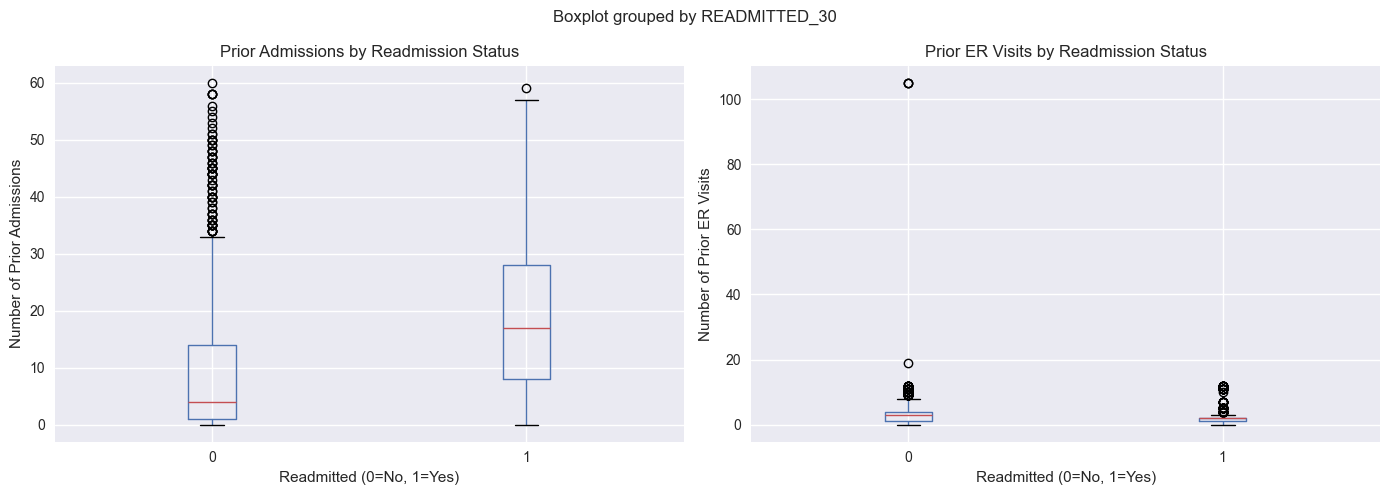

Prior admissions summary:
READMITTED_30
0     9.753040
1    19.501951
Name: PRIOR_ADMISSIONS, dtype: float64

Prior ER visits summary:
READMITTED_30
0    3.507016
1    2.286086
Name: PRIOR_ER_VISITS, dtype: float64


In [15]:
# Cell 9 — Prior Admissions Feature
# Count prior inpatient visits for each encounter
inpatient_sorted = inpatient_patients.sort_values(['PATIENT', 'START'])
inpatient_sorted['PRIOR_ADMISSIONS'] = inpatient_sorted.groupby('PATIENT').cumcount()

# Prior ER visits
er_visits = encounters[encounters['ENCOUNTERCLASS'] == 'emergency'].groupby('PATIENT').size().reset_index(name='PRIOR_ER_VISITS')
inpatient_sorted = inpatient_sorted.merge(er_visits, on='PATIENT', how='left')
inpatient_sorted['PRIOR_ER_VISITS'] = inpatient_sorted['PRIOR_ER_VISITS'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prior admissions vs readmission
inpatient_sorted.boxplot(column='PRIOR_ADMISSIONS', by='READMITTED_30', ax=axes[0])
axes[0].set_title('Prior Admissions by Readmission Status')
axes[0].set_xlabel('Readmitted (0=No, 1=Yes)')
axes[0].set_ylabel('Number of Prior Admissions')

# Prior ER visits vs readmission
inpatient_sorted.boxplot(column='PRIOR_ER_VISITS', by='READMITTED_30', ax=axes[1])
axes[1].set_title('Prior ER Visits by Readmission Status')
axes[1].set_xlabel('Readmitted (0=No, 1=Yes)')
axes[1].set_ylabel('Number of Prior ER Visits')

plt.tight_layout()
plt.savefig('../reports/prior_visits_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Prior admissions summary:")
print(inpatient_sorted.groupby('READMITTED_30')['PRIOR_ADMISSIONS'].mean())
print("\nPrior ER visits summary:")
print(inpatient_sorted.groupby('READMITTED_30')['PRIOR_ER_VISITS'].mean())

# Update our main dataframe
inpatient_patients = inpatient_sorted.copy()

In [16]:
# Cell 10 — EDA Summary Statistics
print("="*50)
print("EDA SUMMARY")
print("="*50)
print(f"\nTotal inpatient encounters: {len(inpatient_patients)}")
print(f"Total unique patients: {inpatient_patients['PATIENT'].nunique()}")
print(f"Overall 30-day readmission rate: {inpatient_patients['READMITTED_30'].mean():.2%}")
print(f"\nTop predictors identified:")
print(f"  - Prior admissions: readmitted=19.5 vs not=9.75")
print(f"  - Total medications: readmitted=111.9 vs not=77.9")
print(f"  - Total procedures: readmitted=91.9 vs not=53.5")
print(f"  - Age group 66-80 has highest readmission rate: 53.2%")
print(f"  - Oncology diagnoses show highest readmission rates")
print(f"\nData quality issues found:")
print(f"  - Length of stay outlier: 485,164 hours (will cap at 99th percentile)")
print(f"  - Small sample sizes for Asian race category")
print(f"\nFeatures to build for modeling:")
print(f"  - AGE, GENDER, RACE (demographics)")
print(f"  - LENGTH_OF_STAY (capped)")
print(f"  - PRIOR_ADMISSIONS, PRIOR_ER_VISITS (history)")
print(f"  - TOTAL_CONDITIONS, TOTAL_MEDICATIONS, TOTAL_PROCEDURES (complexity)")
print(f"  - IS_ONCOLOGY (derived from diagnosis)")

EDA SUMMARY

Total inpatient encounters: 1838
Total unique patients: 283
Overall 30-day readmission rate: 41.84%

Top predictors identified:
  - Prior admissions: readmitted=19.5 vs not=9.75
  - Total medications: readmitted=111.9 vs not=77.9
  - Total procedures: readmitted=91.9 vs not=53.5
  - Age group 66-80 has highest readmission rate: 53.2%
  - Oncology diagnoses show highest readmission rates

Data quality issues found:
  - Length of stay outlier: 485,164 hours (will cap at 99th percentile)
  - Small sample sizes for Asian race category

Features to build for modeling:
  - AGE, GENDER, RACE (demographics)
  - LENGTH_OF_STAY (capped)
  - PRIOR_ADMISSIONS, PRIOR_ER_VISITS (history)
  - TOTAL_CONDITIONS, TOTAL_MEDICATIONS, TOTAL_PROCEDURES (complexity)
  - IS_ONCOLOGY (derived from diagnosis)
